# Root Finding Methods

## Bisection, Secant (Regula Falsi) & Newton's Method

This notebook implements and compares three fundamental algorithms
for solving the nonlinear equation

$$f(x) = 0$$

| Method | Idea | Convergence | Requires |
|--------|------|:-----------:|----------|
| **Bisection** | Halve the bracket | Linear ($\sim 1$ digit / 3 steps) | Sign change on $[a,b]$ |
| **Secant / Regula Falsi** | Linear interpolation | Super-linear (~1.618) | Sign change on $[a,b]$ |
| **Newton's method** | Tangent line | Quadratic (digits double) | Derivative $f'(x)$ |

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — The Three Methods

### 2.1 Bisection

If $f(a)$ and $f(b)$ have opposite signs, a root lies in $[a,b]$.
Evaluate at the midpoint $c = (a+b)/2$ and keep the half where
the sign change occurs.

$$c = \frac{a + b}{2}$$

### 2.2 Secant Method (Regula Falsi)

Instead of the midpoint, use the $x$-intercept of the **secant line**
through $(a, f(a))$ and $(b, f(b))$:

$$c = b - f(b)\,\frac{b - a}{f(b) - f(a)}$$

Then update the bracket the same way as bisection.

### 2.3 Newton's Method

Use the $x$-intercept of the **tangent line** at the current guess:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

This requires the derivative $f'(x)$ but converges **quadratically**
(the number of correct digits roughly doubles each step).

In [2]:
def bisection(f, a, b, tol=1e-10, max_iter=100):
    """
    Bisection method.

    Returns a list of dicts with iteration history.
    Requires f(a)*f(b) < 0.
    """
    fa, fb = f(a), f(b)
    assert fa * fb < 0, "f(a) and f(b) must have opposite signs"

    history = []
    for n in range(1, max_iter + 1):
        c  = (a + b) / 2
        fc = f(c)
        history.append({"n": n, "a": a, "b": b, "c": c,
                        "f(c)": fc, "bracket": b - a})

        if abs(fc) < tol or (b - a) / 2 < tol:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return history


def secant(f, a, b, tol=1e-10, max_iter=100):
    """
    Secant method (regula falsi / false position).

    Uses linear interpolation instead of the midpoint.
    Requires f(a)*f(b) < 0.
    """
    fa, fb = f(a), f(b)
    assert fa * fb < 0, "f(a) and f(b) must have opposite signs"

    history = []
    for n in range(1, max_iter + 1):
        c  = b - fb * (b - a) / (fb - fa)
        fc = f(c)
        history.append({"n": n, "a": a, "b": b, "c": c,
                        "f(c)": fc, "bracket": b - a})

        if abs(fc) < tol:
            break
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return history


def newton(f, fp, x0, tol=1e-10, max_iter=100):
    """
    Newton's method.

    f  : the function
    fp : the derivative f'
    x0 : initial guess
    """
    x = x0
    history = []
    for n in range(1, max_iter + 1):
        fx  = f(x)
        fpx = fp(x)
        if abs(fpx) < 1e-15:
            break                     # zero derivative — can't continue
        x_new = x - fx / fpx
        history.append({"n": n, "x": x, "f(x)": fx,
                        "f'(x)": fpx, "x_new": x_new})
        if abs(x_new - x) < tol:
            break
        x = x_new
    return history

## 3 — Test Problem

$$f(x) = x^3 - x - 2$$

This has a root near $x \approx 1.5214$.

In [3]:
f  = lambda x: x**3 - x - 2
fp = lambda x: 3*x**2 - 1          # derivative for Newton

a, b = 1.0, 2.0

h_bisect = bisection(f, a, b)
h_secant = secant(f, a, b)
h_newton = newton(f, fp, x0=2.0)   # start from right endpoint

## 4 — Iteration Tables

In [4]:
def print_bracket_table(history, name):
    print(f"\n{'='*70}")
    print(f"  {name}")
    print(f"{'='*70}")
    print(f"{'n':>3}  {'a':>12}  {'b':>12}  {'c':>12}  {'f(c)':>12}  {'bracket':>10}")
    print("-" * 70)
    for h in history:
        print(f"{h['n']:>3}  {h['a']:>12.8f}  {h['b']:>12.8f}  "
              f"{h['c']:>12.8f}  {h['f(c)']:>12.2e}  {h['bracket']:>10.2e}")


def print_newton_table(history):
    print(f"\n{'='*70}")
    print(f"  Newton's Method")
    print(f"{'='*70}")
    header = f"{'n':>3}  {'x_n':>14}  {'f(x_n)':>12}  {'fp(x_n)':>12}  {'x_next':>14}"
    print(header)
    print("-" * 70)
    for h in history:
        fpx = h["f'(x)"]
        print(f"{h['n']:>3}  {h['x']:>14.10f}  {h['f(x)']:>12.2e}  "
              f"{fpx:>12.4f}  {h['x_new']:>14.10f}")


print_bracket_table(h_bisect, "Bisection")
print_bracket_table(h_secant, "Secant (Regula Falsi)")
print_newton_table(h_newton)

print(f"\nIterations needed:  Bisection = {len(h_bisect)},  "
      f"Secant = {len(h_secant)},  Newton = {len(h_newton)}")



  Bisection
  n             a             b             c          f(c)     bracket
----------------------------------------------------------------------
  1    1.00000000    2.00000000    1.50000000     -1.25e-01    1.00e+00
  2    1.50000000    2.00000000    1.75000000      1.61e+00    5.00e-01
  3    1.50000000    1.75000000    1.62500000      6.66e-01    2.50e-01
  4    1.50000000    1.62500000    1.56250000      2.52e-01    1.25e-01
  5    1.50000000    1.56250000    1.53125000      5.91e-02    6.25e-02
  6    1.50000000    1.53125000    1.51562500     -3.41e-02    3.12e-02
  7    1.51562500    1.53125000    1.52343750      1.23e-02    1.56e-02
  8    1.51562500    1.52343750    1.51953125     -1.10e-02    7.81e-03
  9    1.51953125    1.52343750    1.52148438      6.22e-04    3.91e-03
 10    1.51953125    1.52148438    1.52050781     -5.18e-03    1.95e-03
 11    1.52050781    1.52148438    1.52099609     -2.28e-03    9.77e-04
 12    1.52099609    1.52148438    1.52124023     -8

## 5 — Visual Comparison: Convergence

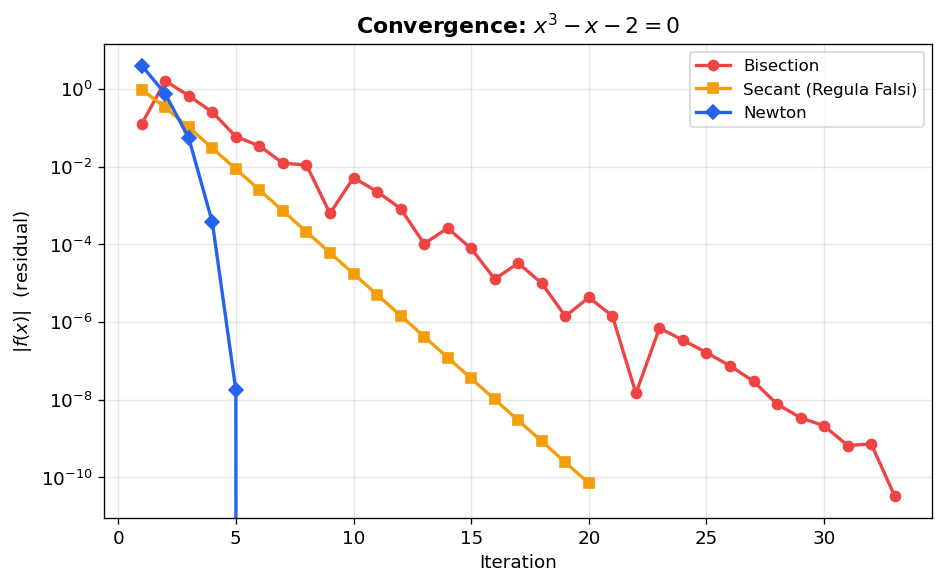

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Bisection: |f(c)|
ns = [h["n"] for h in h_bisect]
errs = [abs(h["f(c)"]) for h in h_bisect]
ax.semilogy(ns, errs, "o-", color="#ef4444", lw=2, markersize=6,
            label="Bisection")

# Secant: |f(c)|
ns = [h["n"] for h in h_secant]
errs = [abs(h["f(c)"]) for h in h_secant]
ax.semilogy(ns, errs, "s-", color="#f59e0b", lw=2, markersize=6,
            label="Secant (Regula Falsi)")

# Newton: |f(x)|
ns = [h["n"] for h in h_newton]
errs = [abs(h["f(x)"]) for h in h_newton]
ax.semilogy(ns, errs, "D-", color="#2563eb", lw=2, markersize=6,
            label="Newton")

ax.set_xlabel("Iteration")
ax.set_ylabel("$|f(x)|$  (residual)")
ax.set_title("Convergence: $x^3 - x - 2 = 0$", fontweight="bold")
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

## 6 — Geometric Visualisation

Each method works differently *geometrically*:
- **Bisection** — always picks the midpoint
- **Secant** — draws a straight line through $(a, f(a))$ and $(b, f(b))$
- **Newton** — draws the tangent line at the current guess

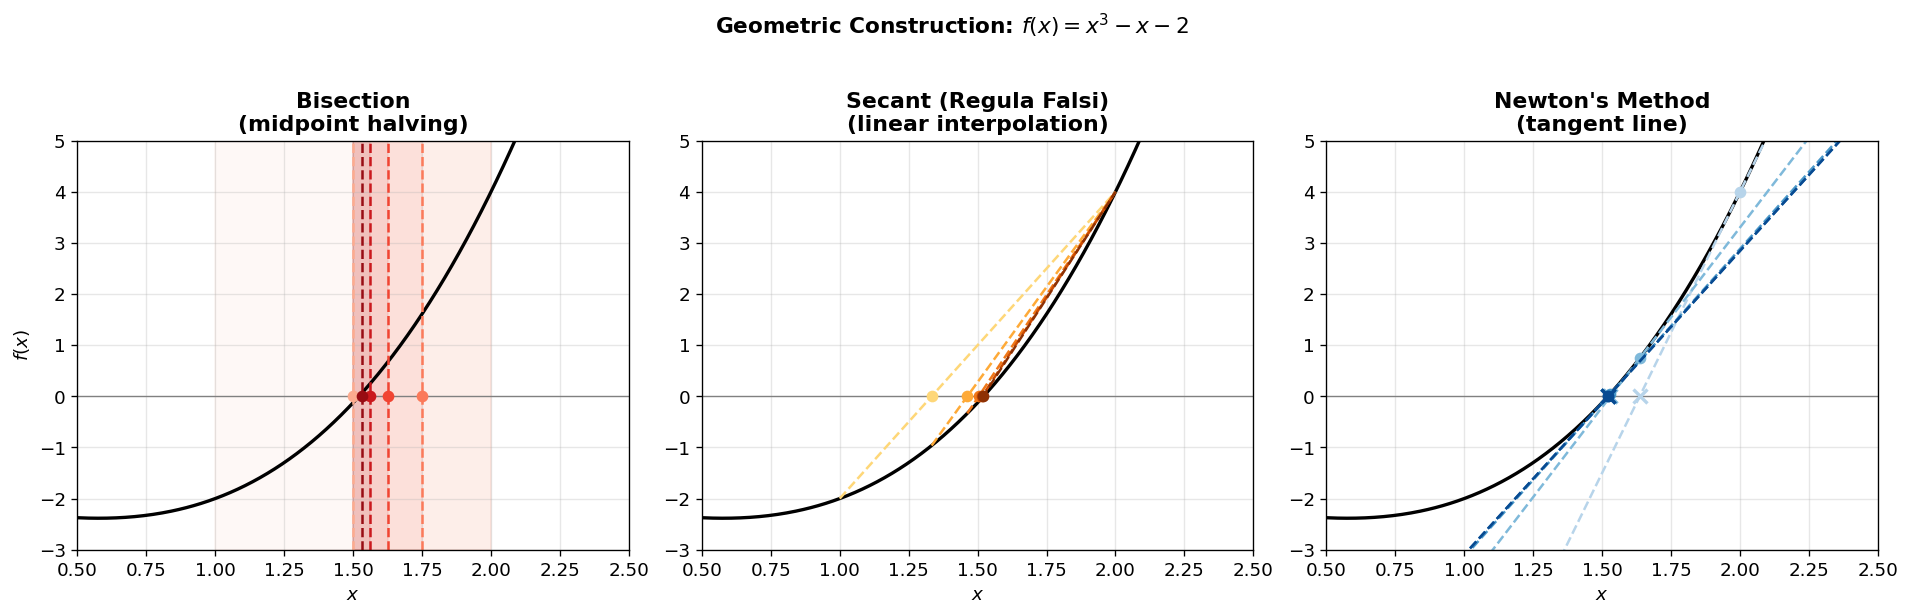

In [6]:
x_plot = np.linspace(0.5, 2.5, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Bisection ---
ax = axes[0]
ax.plot(x_plot, f(x_plot), "k-", lw=2)
ax.axhline(0, color="grey", lw=0.8)
colors_b = plt.cm.Reds(np.linspace(0.3, 0.9, min(5, len(h_bisect))))
for i, (h, col) in enumerate(zip(h_bisect[:5], colors_b)):
    ax.axvspan(h["a"], h["b"], alpha=0.08, color=col)
    ax.axvline(h["c"], color=col, ls="--", lw=1.5)
    ax.plot(h["c"], 0, "o", color=col, markersize=6)
ax.set_title("Bisection\n(midpoint halving)", fontweight="bold")
ax.set_xlabel("$x$"); ax.set_ylabel("$f(x)$")

# --- Secant ---
ax = axes[1]
ax.plot(x_plot, f(x_plot), "k-", lw=2)
ax.axhline(0, color="grey", lw=0.8)
colors_s = plt.cm.YlOrBr(np.linspace(0.3, 0.9, min(5, len(h_secant))))
for i, (h, col) in enumerate(zip(h_secant[:5], colors_s)):
    # Secant line
    ax.plot([h["a"], h["b"]], [f(h["a"]), f(h["b"])],
            "--", color=col, lw=1.5)
    ax.plot(h["c"], 0, "o", color=col, markersize=6)
ax.set_title("Secant (Regula Falsi)\n(linear interpolation)",
             fontweight="bold")
ax.set_xlabel("$x$")

# --- Newton ---
ax = axes[2]
ax.plot(x_plot, f(x_plot), "k-", lw=2)
ax.axhline(0, color="grey", lw=0.8)
colors_n = plt.cm.Blues(np.linspace(0.3, 0.9, min(5, len(h_newton))))
for i, (h, col) in enumerate(zip(h_newton[:5], colors_n)):
    xn  = h["x"]
    fxn = h["f(x)"]
    fpn = h["f'(x)"]
    # Tangent line
    x_tan = np.linspace(xn - 1, xn + 1, 50)
    y_tan = fxn + fpn * (x_tan - xn)
    ax.plot(x_tan, y_tan, "--", color=col, lw=1.5)
    ax.plot(xn, fxn, "o", color=col, markersize=6)
    ax.plot(h["x_new"], 0, "x", color=col, markersize=8, mew=2)
ax.set_title("Newton's Method\n(tangent line)", fontweight="bold")
ax.set_xlabel("$x$")

for ax in axes:
    ax.set_xlim(0.5, 2.5)
    ax.set_ylim(-3, 5)

fig.suptitle("Geometric Construction: $f(x) = x^3 - x - 2$",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 7 — Convergence Orders

### 7.1 Newton: Quadratic Convergence

If convergence is quadratic, then
$\log|e_{n+1}| \approx 2\,\log|e_n| + \text{const}$.
On a log–log plot of successive errors, the slope should be $\approx 2$.

Root = 1.521379706804568


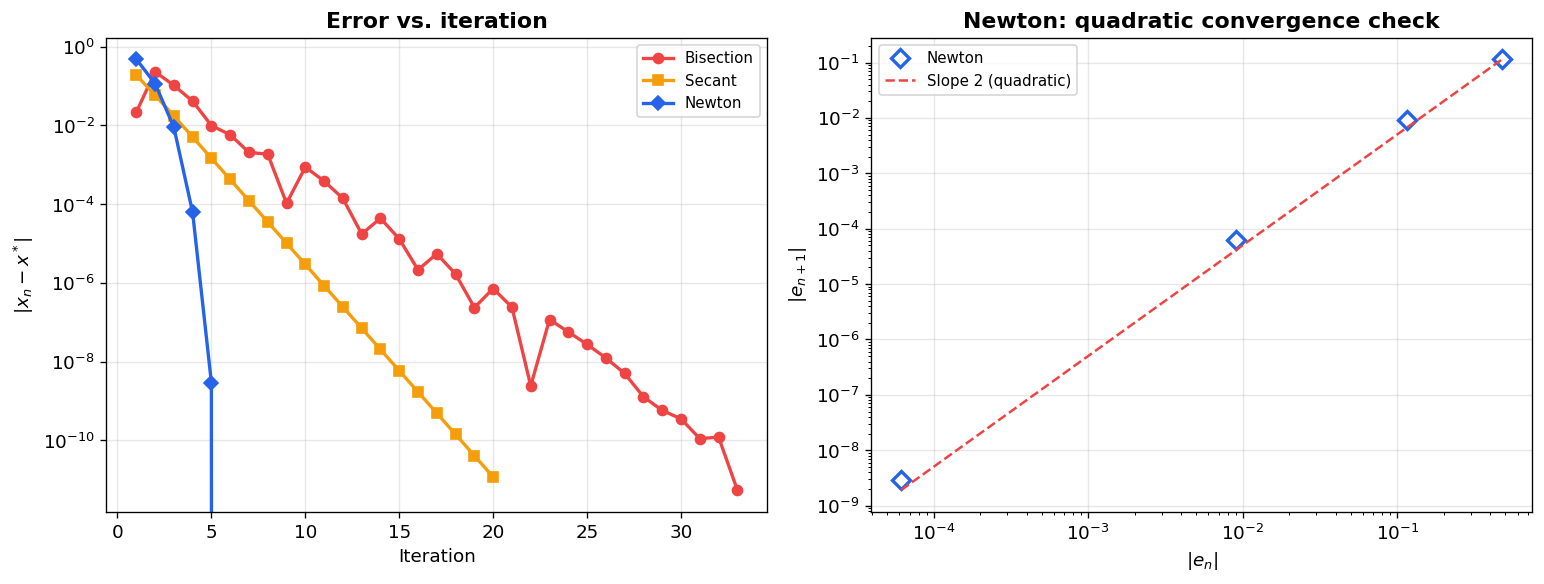

In [7]:
# Find the root to high precision
h_ref = newton(f, fp, 2.0, tol=1e-15)
root = h_ref[-1]["x_new"]
print(f"Root = {root:.15f}")

# Errors for each method
errors_bisect = [abs(h["c"] - root) for h in h_bisect]
errors_secant = [abs(h["c"] - root) for h in h_secant]
errors_newton = [abs(h["x"] - root) for h in h_newton]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: error vs iteration
ax1.semilogy(range(1, len(errors_bisect)+1), errors_bisect, "o-",
             color="#ef4444", lw=2, label="Bisection")
ax1.semilogy(range(1, len(errors_secant)+1), errors_secant, "s-",
             color="#f59e0b", lw=2, label="Secant")
ax1.semilogy(range(1, len(errors_newton)+1), errors_newton, "D-",
             color="#2563eb", lw=2, label="Newton")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("$|x_n - x^*|$")
ax1.set_title("Error vs. iteration", fontweight="bold")
ax1.legend(fontsize=9)

# Right: log-log successive errors (Newton) — slope ≈ 2
e_n = [e for e in errors_newton if e > 0]
if len(e_n) > 2:
    ax2.loglog(e_n[:-1], e_n[1:], "D", color="#2563eb", markersize=8,
              markerfacecolor="white", markeredgewidth=2, label="Newton")
    # Reference slope 2
    e_ref = np.logspace(np.log10(min(e_n[:-1])), np.log10(max(e_n[:-1])), 50)
    C = e_n[1] / e_n[0]**2
    ax2.loglog(e_ref, C * e_ref**2, "--", color="#ef4444", lw=1.5,
              label="Slope 2 (quadratic)")

ax2.set_xlabel("$|e_n|$")
ax2.set_ylabel("$|e_{n+1}|$")
ax2.set_title("Newton: quadratic convergence check", fontweight="bold")
ax2.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 8 — Comparison Across Different Functions

In [8]:
problems = [
    (r"$x^3 - x - 2$",        lambda x: x**3 - x - 2,
                               lambda x: 3*x**2 - 1,          1, 2),
    (r"$\cos(x) - x$",        lambda x: np.cos(x) - x,
                               lambda x: -np.sin(x) - 1,      0, 1),
    (r"$e^{-x} - x$",         lambda x: np.exp(-x) - x,
                               lambda x: -np.exp(-x) - 1,     0, 1),
    (r"$x^2 - 2$ ($\sqrt{2}$)",lambda x: x**2 - 2,
                               lambda x: 2*x,                 1, 2),
]

print(f"{'Problem':<25} {'Bisect':>8} {'Secant':>8} {'Newton':>8}  {'Root':>16}")
print("=" * 72)

for label, fi, fpi, ai, bi in problems:
    hb = bisection(fi, ai, bi)
    hs = secant(fi, ai, bi)
    hn = newton(fi, fpi, bi)
    root_val = hn[-1]["x_new"]
    print(f"{label:<25} {len(hb):>8} {len(hs):>8} {len(hn):>8}  {root_val:>16.12f}")

Problem                     Bisect   Secant   Newton              Root
$x^3 - x - 2$                   33       20        6    1.521379706805
$\cos(x) - x$                   30        8        5    0.739085133215
$e^{-x} - x$                    33       11        5    0.567143290410
$x^2 - 2$ ($\sqrt{2}$)          29       14        5    1.414213562373


## 9 — When Newton Fails

Newton's method is not foolproof. It can:
- **Cycle** if the initial guess is near a local extremum
- **Diverge** if the derivative is close to zero
- **Jump to the wrong root** for functions with multiple roots

Bisection, on the other hand, **always converges** as long as
there is a sign change — it is the most robust method.

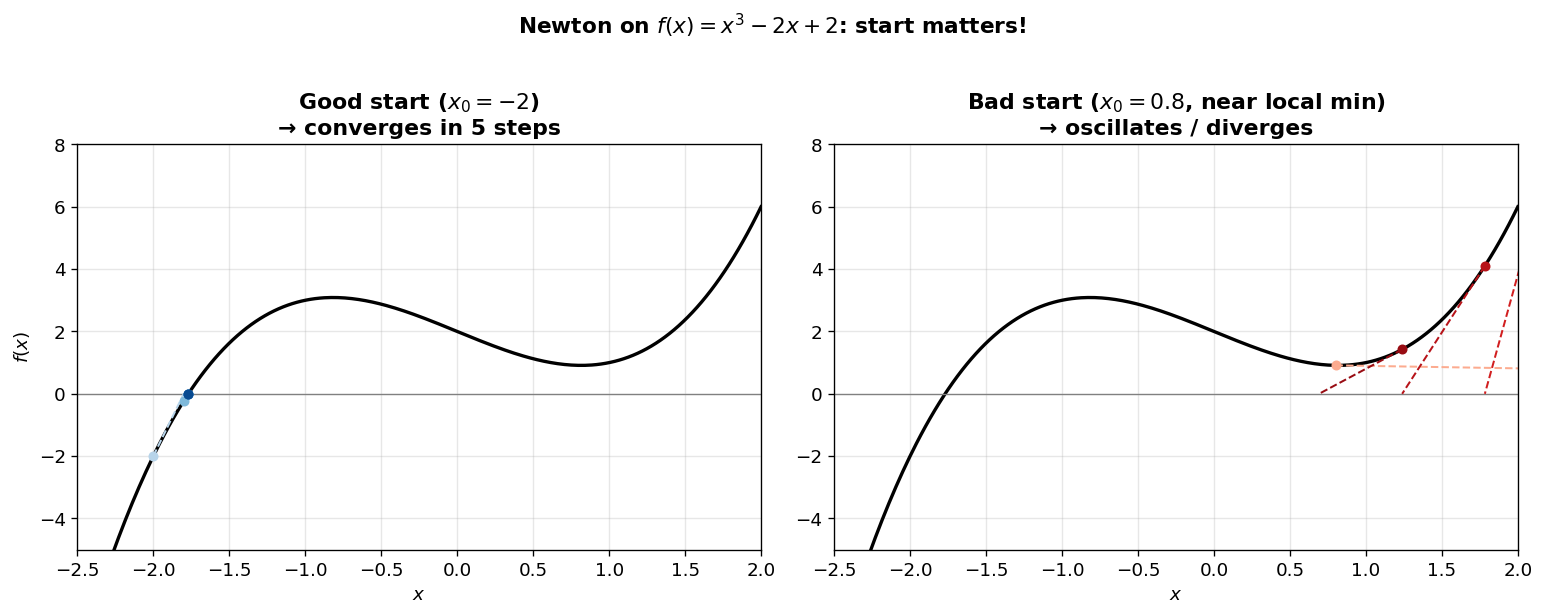

In [9]:
# Newton failure example:  f(x) = x^3 - 2x + 2,  starting near the local min
f_bad  = lambda x: x**3 - 2*x + 2
fp_bad = lambda x: 3*x**2 - 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x_plot = np.linspace(-2.5, 2, 300)

# Left: Newton from a good start → converges
ax1.plot(x_plot, f_bad(x_plot), "k-", lw=2)
ax1.axhline(0, color="grey", lw=0.8)
h_good = newton(f_bad, fp_bad, x0=-2.0, tol=1e-10)
cols = plt.cm.Blues(np.linspace(0.3, 0.9, len(h_good)))
for h, col in zip(h_good, cols):
    xn = h["x"]
    ax1.plot([xn, h["x_new"]], [h["f(x)"], 0], "--", color=col, lw=1.2)
    ax1.plot(xn, h["f(x)"], "o", color=col, markersize=5)
ax1.set_title(f"Good start ($x_0 = -2$)\n→ converges in {len(h_good)} steps",
              fontweight="bold")
ax1.set_xlim(-2.5, 2); ax1.set_ylim(-5, 8)
ax1.set_xlabel("$x$"); ax1.set_ylabel("$f(x)$")

# Right: Newton from a bad start → oscillates
ax2.plot(x_plot, f_bad(x_plot), "k-", lw=2)
ax2.axhline(0, color="grey", lw=0.8)
h_bad = newton(f_bad, fp_bad, x0=0.8, tol=1e-10, max_iter=8)
cols = plt.cm.Reds(np.linspace(0.3, 0.9, len(h_bad)))
for h, col in zip(h_bad, cols):
    xn = h["x"]
    ax2.plot([xn, h["x_new"]], [h["f(x)"], 0], "--", color=col, lw=1.2)
    ax2.plot(xn, h["f(x)"], "o", color=col, markersize=5)
ax2.set_title(f"Bad start ($x_0 = 0.8$, near local min)\n→ oscillates / diverges",
              fontweight="bold")
ax2.set_xlim(-2.5, 2); ax2.set_ylim(-5, 8)
ax2.set_xlabel("$x$")

fig.suptitle(r"Newton on $f(x) = x^3 - 2x + 2$: start matters!",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 10 — Hybrid Strategy

In practice, production solvers combine methods:
start with a few bisection steps to get a safe bracket, then
switch to a faster method.

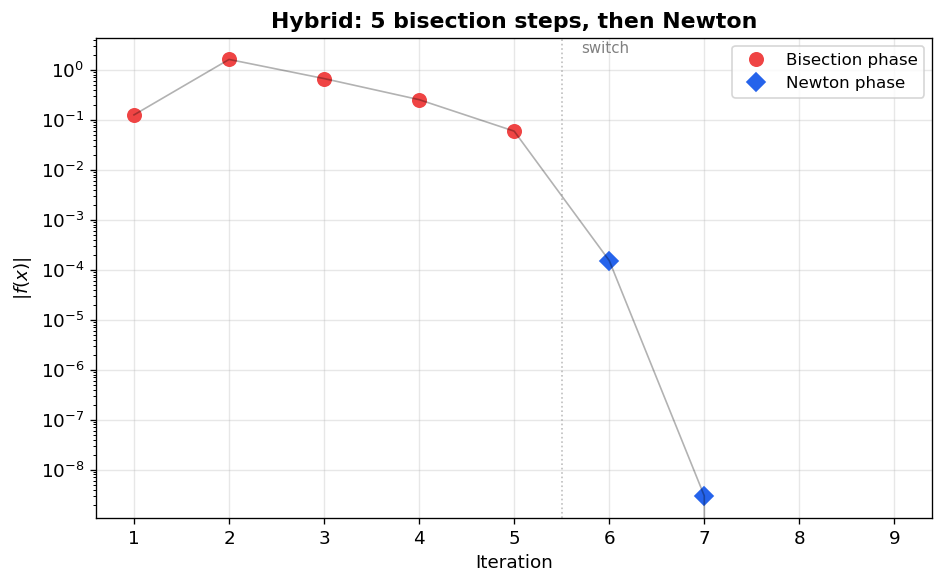

In [10]:
def hybrid(f, fp, a, b, tol=1e-12, bisect_steps=5):
    """
    Hybrid: use bisection to narrow the bracket, then
    switch to Newton for fast quadratic convergence.
    """
    fa, fb = f(a), f(b)
    history = []

    # Phase 1: Bisection
    for n in range(1, bisect_steps + 1):
        c = (a + b) / 2
        fc = f(c)
        history.append({"n": n, "x": c, "|f(x)|": abs(fc),
                        "method": "Bisection"})
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

    # Phase 2: Newton from the current midpoint
    x = (a + b) / 2
    for n in range(bisect_steps + 1, bisect_steps + 30):
        fx = f(x)
        fpx = fp(x)
        if abs(fpx) < 1e-15:
            break
        x_new = x - fx / fpx
        history.append({"n": n, "x": x_new, "|f(x)|": abs(f(x_new)),
                        "method": "Newton"})
        if abs(x_new - x) < tol:
            break
        x = x_new

    return history


f  = lambda x: x**3 - x - 2
fp = lambda x: 3*x**2 - 1

h_hybrid = hybrid(f, fp, 1, 2)

fig, ax = plt.subplots(figsize=(8, 5))
for h in h_hybrid:
    col = "#ef4444" if h["method"] == "Bisection" else "#2563eb"
    marker = "o" if h["method"] == "Bisection" else "D"
    ax.semilogy(h["n"], h["|f(x)|"], marker, color=col, markersize=8)

# Connect with lines
ns = [h["n"] for h in h_hybrid]
errs = [h["|f(x)|"] for h in h_hybrid]
ax.semilogy(ns, errs, "k-", lw=1, alpha=0.3)

ax.semilogy([], [], "o", color="#ef4444", markersize=8, label="Bisection phase")
ax.semilogy([], [], "D", color="#2563eb", markersize=8, label="Newton phase")
ax.axvline(5.5, color="grey", ls=":", lw=1, alpha=0.5)
ax.text(5.7, ax.get_ylim()[1]*0.5, "switch", fontsize=9, color="grey")

ax.set_xlabel("Iteration")
ax.set_ylabel("$|f(x)|$")
ax.set_title("Hybrid: 5 bisection steps, then Newton", fontweight="bold")
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

## 11 — Notes for Students

### Key take-aways

1. **Bisection is bulletproof** — it always converges if there is a
   sign change, but it is slow (1 binary digit per step).

2. **Secant / Regula Falsi** interpolates linearly between two
   bracketing points. It converges faster than bisection (~order 1.618)
   while still maintaining a bracket.

3. **Newton's method** is the fastest (quadratic convergence) but
   needs $f'(x)$ and a good initial guess. Near a local extremum
   or inflection point, it can fail.

4. **Hybrid strategies** combine the safety of bisection with the
   speed of Newton — this is what `scipy.optimize.brentq` does
   internally.

5. **Convergence order** — Bisection: linear ($O(1/2^n)$),
   Secant: super-linear ($O(\phi^{-n})$ where $\phi = 1.618$),
   Newton: quadratic ($O(c^{2^n})$).

### Exercises

1. Find $\sqrt{3}$ using all three methods on $f(x) = x^2 - 3$.
   Count how many iterations each needs for 10 correct digits.

2. Newton's method for $f(x) = x^2$ (double root at $x=0$) converges
   only *linearly*. Verify this numerically and explain why.

3. Implement the **secant method without bracketing** (use the two
   most recent points, not necessarily a sign-change bracket).
   Does it converge faster than regula falsi? Is it still safe?

4. Compare your implementations with `scipy.optimize.brentq`
   (Brent's method) and `scipy.optimize.newton`. How many
   function evaluations does each use?

5. For Newton's method, replace the exact derivative with a
   numerical approximation $f'(x) \approx (f(x+h) - f(x))/h$.
   How small must $h$ be to preserve quadratic convergence?